**Advanced Features**
-

1. Token Features
- CWC_min (Common Word/ min(word count(q1,q2)))
- CWC_max (Common word/ max(word count(q1,q2)))
- CTC_min (Common Tokens/ min(tokens count(q1,q2)))
- CTC_max (Common Tokens/ max(tokens count(q1,q2)))
- CSC_min (Common Stopwords/ min(tokens count(q1,q2)))
- CSC_max (Common Stopwords/ max(tokens count(q1,q2)))
- last_word_eq
- first_word_eq

2. Length Based Features
- mean_len
- abs_len_diff
- Longest_substr_ratio

3. Fuzzy Features
- fuzz_ratio : fuzz_ratio score from fuzzywuzzy
- fuzz_partial_ratio : fuzz_partial_ratio from fuzzywuzzy
- fuzz_sort_ratio : fuzz_sort_ratio from fuzzywuzzy
- fuzz_set_ratio : fuzz_set_ratio from fuzzywuzzy

In [83]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
import re 
from bs4 import BeautifulSoup

In [85]:
df = pd.read_csv('train.csv')
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [86]:
sample = df.sample(30000,random_state=42)


In [87]:
sample.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [88]:
sample.duplicated().sum()

np.int64(0)

In [89]:
sample.head()

,id,qid1,qid2,question1,question2,is_duplicate
8067,8067,15738,15739,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?,0
368101,368101,12736,104117,What are some of the best side dishes for crab...,What are some good side dishes for buffalo chi...,0
70497,70497,121486,121487,Which is more advisable and better material fo...,What is the best server setup for buddypress?,0
226567,226567,254474,258192,How do I improve logical programming skills?,How can I improve my logical skills for progra...,1
73186,73186,48103,3062,How close we are to see 3rd world war?,How close is a World War III?,1


In [146]:
def preprocessing(q):

    #convert to lower order
    q = str(q).lower().strip()

    #Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')

    #The pattern '[math]' appears around 900 times in the whole dataset.
    q = q.replace('[math]','')

    # Replacing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)


    #Decontracting words
    # https://en.wikipedia.org/wiki/Wikipedia%3aList_of_English_contractions
    # https://stackoverflow.com/a/19794953
    contractions = { 
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]
        
        q_decontracted.append(word)
    
    q = ' '.join(q_decontracted)


    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")

    # Remove Html Tags
    q = BeautifulSoup(q, 'html.parser')
    q = q.get_text()

    #Remove Punctuations
    pattern = re.compile(r'[^\w\s]')
    q = re.sub(pattern,' ',q).strip()

    return q

In [147]:
#Example
preprocessing("I am Divyansh Parihar and I've <b>completed</b> my 12th")

'i am divyansh parihar and i have completed my 12th'

In [148]:
sample['question1'] = sample['question1'].apply(preprocessing)
sample['question2'] = sample['question2'].apply(preprocessing)

In [149]:
sample.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,word_count1,word_count2,...,ctc_max,last_word_eq,first_word_eq,Abs_len_diff,Mean_Len,longest_substr_rt,Fuzzy_ratio,Fuzzy_partial_ratio,Fuzzy_token_sort_ratio,Fuzzy_token_set_ratio
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,1.999975,0.0,1.0,0.0,8.0,0.823529,88.0,88.0,81.0,90.0
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,1.818165,0.0,1.0,2.0,10.0,0.333333,73.0,72.0,73.0,73.0
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,95,44,16,8,...,1.499991,0.0,0.0,8.0,12.0,0.111111,35.0,43.0,36.0,24.0
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,1.777758,0.0,1.0,2.0,8.0,0.272727,72.0,67.0,89.0,96.0
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,1.777758,0.0,1.0,2.0,8.0,0.344828,68.0,61.0,71.0,81.0


In [150]:
sample['q1_len'] = sample['question1'].apply(len)
sample['q2_len'] = sample['question2'].apply(len)
sample.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,word_count1,word_count2,...,ctc_max,last_word_eq,first_word_eq,Abs_len_diff,Mean_Len,longest_substr_rt,Fuzzy_ratio,Fuzzy_partial_ratio,Fuzzy_token_sort_ratio,Fuzzy_token_set_ratio
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,1.999975,0.0,1.0,0.0,8.0,0.823529,88.0,88.0,81.0,90.0
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,1.818165,0.0,1.0,2.0,10.0,0.333333,73.0,72.0,73.0,73.0
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,...,1.499991,0.0,0.0,8.0,12.0,0.111111,35.0,43.0,36.0,24.0
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,1.777758,0.0,1.0,2.0,8.0,0.272727,72.0,67.0,89.0,96.0
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,1.777758,0.0,1.0,2.0,8.0,0.344828,68.0,61.0,71.0,81.0


In [151]:
sample['word_count1'] = sample['question1'].str.split().apply(len)
sample['word_count2'] = sample['question2'].str.split().apply(len)
sample.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,word_count1,word_count2,...,ctc_max,last_word_eq,first_word_eq,Abs_len_diff,Mean_Len,longest_substr_rt,Fuzzy_ratio,Fuzzy_partial_ratio,Fuzzy_token_sort_ratio,Fuzzy_token_set_ratio
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,1.999975,0.0,1.0,0.0,8.0,0.823529,88.0,88.0,81.0,90.0
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,1.818165,0.0,1.0,2.0,10.0,0.333333,73.0,72.0,73.0,73.0
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,...,1.499991,0.0,0.0,8.0,12.0,0.111111,35.0,43.0,36.0,24.0
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,1.777758,0.0,1.0,2.0,8.0,0.272727,72.0,67.0,89.0,96.0
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,1.777758,0.0,1.0,2.0,8.0,0.344828,68.0,61.0,71.0,81.0


In [152]:
def common_word(row):
    q1_set = set(map(lambda word: word.strip(), row['question1'].split()))
    q2_set = set(map(lambda word: word.strip(), row['question2'].split()))
    return len(q1_set & q2_set)

In [153]:
q1_set = set(map(lambda word: word.lower().strip(), 'how do i monetize my business website'.split()))
q1_set

{'business', 'do', 'how', 'i', 'monetize', 'my', 'website'}

In [154]:
sample['common_word_count'] = sample.apply(common_word, axis=1)


In [155]:
sample.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,word_count1,word_count2,...,ctc_max,last_word_eq,first_word_eq,Abs_len_diff,Mean_Len,longest_substr_rt,Fuzzy_ratio,Fuzzy_partial_ratio,Fuzzy_token_sort_ratio,Fuzzy_token_set_ratio
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,1.999975,0.0,1.0,0.0,8.0,0.823529,88.0,88.0,81.0,90.0
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,1.818165,0.0,1.0,2.0,10.0,0.333333,73.0,72.0,73.0,73.0
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,...,1.499991,0.0,0.0,8.0,12.0,0.111111,35.0,43.0,36.0,24.0
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,1.777758,0.0,1.0,2.0,8.0,0.272727,72.0,67.0,89.0,96.0
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,1.777758,0.0,1.0,2.0,8.0,0.344828,68.0,61.0,71.0,81.0


In [156]:
def Total_word(row):
    q1_set = set(map(lambda word: word.strip(), row['question1'].split()))
    q2_set = set(map(lambda word: word.strip(), row['question2'].split()))
    return (len(q1_set) + len(q2_set))

In [157]:
sample['total_word_count'] = sample.apply(Total_word,axis=1)
sample.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,word_count1,word_count2,...,ctc_max,last_word_eq,first_word_eq,Abs_len_diff,Mean_Len,longest_substr_rt,Fuzzy_ratio,Fuzzy_partial_ratio,Fuzzy_token_sort_ratio,Fuzzy_token_set_ratio
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,1.999975,0.0,1.0,0.0,8.0,0.823529,88.0,88.0,81.0,90.0
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,1.818165,0.0,1.0,2.0,10.0,0.333333,73.0,72.0,73.0,73.0
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,...,1.499991,0.0,0.0,8.0,12.0,0.111111,35.0,43.0,36.0,24.0
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,1.777758,0.0,1.0,2.0,8.0,0.272727,72.0,67.0,89.0,96.0
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,1.777758,0.0,1.0,2.0,8.0,0.344828,68.0,61.0,71.0,81.0


In [158]:
sample['common_share'] = sample['common_word_count']/ sample['total_word_count']
sample.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,word_count1,word_count2,...,ctc_max,last_word_eq,first_word_eq,Abs_len_diff,Mean_Len,longest_substr_rt,Fuzzy_ratio,Fuzzy_partial_ratio,Fuzzy_token_sort_ratio,Fuzzy_token_set_ratio
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,1.999975,0.0,1.0,0.0,8.0,0.823529,88.0,88.0,81.0,90.0
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,1.818165,0.0,1.0,2.0,10.0,0.333333,73.0,72.0,73.0,73.0
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,...,1.499991,0.0,0.0,8.0,12.0,0.111111,35.0,43.0,36.0,24.0
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,1.777758,0.0,1.0,2.0,8.0,0.272727,72.0,67.0,89.0,96.0
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,1.777758,0.0,1.0,2.0,8.0,0.344828,68.0,61.0,71.0,81.0


Advance Features

Token Features


In [159]:
from nltk.corpus import stopwords

In [160]:
def fetch_token_features(row):
    q1 = row['question1']
    q2 = row['question2']
    
    Safe_Div = 0.0001
    stop_words = stopwords.words('english')
    token_features = [0.0]*8
    
    # Converting the Sentence into Tokens
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) ==0:
        return token_features
    
    # GEt the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in stop_words])
    q2_words = set([word for word in q2_tokens if word not in stop_words])

    # Get the Stopwords in Questions
    q1_stop = set([word for word in q1_tokens if word in stop_words])
    q2_stop = set([word for word in q2_tokens if word in stop_words])

    # Get the Common non-stopwords in Question pair
    word_common_count = len(q1_words & q2_words)

    # Get the Common stopwords in Question Pair
    common_stopwords_count = len(q1_stop & q2_stop)

    # Get the common Tokens in Questions Pair
    common_tokens_count = len(set(q1_tokens)) + len(set(q2_tokens))

    token_features[0] = word_common_count / (min(len(q1_words),len(q2_words)) + Safe_Div)
    token_features[1] = word_common_count / (max(len(q1_words),len(q2_words)) + Safe_Div)
    token_features[2] = common_stopwords_count / (min(len(q1_stop),len(q2_stop)) + Safe_Div)
    token_features[3] = common_stopwords_count / (max(len(q1_stop),len(q2_stop)) + Safe_Div)
    token_features[4] = common_tokens_count / (min(len(q1_tokens),len(q2_tokens)) + Safe_Div)
    token_features[5] = common_tokens_count / (max(len(q1_tokens),len(q2_tokens)) + Safe_Div)

    # Last Word Same or Not of Both The Questions
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # First Word Same or not Of Both The Questions
    token_features[7] = int(q1_tokens[0] == q2_tokens[0]) 

    return token_features


In [161]:
token_features = sample.apply(fetch_token_features, axis=1)

sample["cwc_min"]       = list(map(lambda x: x[0], token_features))
sample["cwc_max"]       = list(map(lambda x: x[1], token_features))
sample["csc_min"]       = list(map(lambda x: x[2], token_features))
sample["csc_max"]       = list(map(lambda x: x[3], token_features))
sample["ctc_min"]       = list(map(lambda x: x[4], token_features))
sample["ctc_max"]       = list(map(lambda x: x[5], token_features))
sample["last_word_eq"]  = list(map(lambda x: x[6], token_features))
sample["first_word_eq"] = list(map(lambda x: x[7], token_features))

In [162]:
sample.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,word_count1,word_count2,...,ctc_max,last_word_eq,first_word_eq,Abs_len_diff,Mean_Len,longest_substr_rt,Fuzzy_ratio,Fuzzy_partial_ratio,Fuzzy_token_sort_ratio,Fuzzy_token_set_ratio
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,1.999975,0.0,1.0,0.0,8.0,0.823529,88.0,88.0,81.0,90.0
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,1.818165,0.0,1.0,2.0,10.0,0.333333,73.0,72.0,73.0,73.0
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,...,1.499991,0.0,0.0,8.0,12.0,0.111111,35.0,43.0,36.0,24.0
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,1.777758,0.0,1.0,2.0,8.0,0.272727,72.0,67.0,89.0,96.0
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,1.777758,0.0,1.0,2.0,8.0,0.344828,68.0,61.0,71.0,81.0


Length based Features


In [163]:
import distance 

def fetch_length_fetures(row):

    q1 = row['question1']
    q2 = row['question2']

    length_feature = [0.0]*3

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_feature

    # Absolute Length Difference 
    length_feature[0] = abs(len(q1_tokens) - len(q2_tokens))

    # Average Token Lentgh OF Both th Questions
    length_feature[1] = (len(q1_tokens) + len(q2_tokens))/2

    strr = list(distance.lcsubstrings(q1,q2))
    if len(strr) == 0:
        length_feature[2] = 0
    else:
        length_feature[2] = len(strr[0]) / (min(len(q1), len(q2)) + 1)

    return length_feature


In [164]:
length_feature =  sample.apply(fetch_length_fetures,axis=1)

sample['Abs_len_diff'] = list(map(lambda x: x[0],length_feature))
sample['Mean_Len'] = list(map(lambda x: x[1], length_feature))
sample['longest_substr_rt'] = list(map(lambda x: x[2],length_feature))


In [165]:
sample.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,word_count1,word_count2,...,ctc_max,last_word_eq,first_word_eq,Abs_len_diff,Mean_Len,longest_substr_rt,Fuzzy_ratio,Fuzzy_partial_ratio,Fuzzy_token_sort_ratio,Fuzzy_token_set_ratio
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,1.999975,0.0,1.0,0.0,8.0,0.823529,88.0,88.0,81.0,90.0
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,1.818165,0.0,1.0,2.0,10.0,0.333333,73.0,72.0,73.0,73.0
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,...,1.499991,0.0,0.0,8.0,12.0,0.111111,35.0,43.0,36.0,24.0
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,1.777758,0.0,1.0,2.0,8.0,0.272727,72.0,67.0,89.0,96.0
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,1.777758,0.0,1.0,2.0,8.0,0.344828,68.0,61.0,71.0,81.0


Fuzzy Features


In [166]:
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):

    q1 = row['question1']
    q2 = row['question2']

    fuzzy_feature = [0.0]*4

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens)==0 or len(q2_tokens)==0:
        return fuzzy_feature
    
    # Get Fuzz Ratio
    fuzzy_feature[0] = fuzz.ratio(q1,q2)

    # Get Fuzzy Partial Ratio
    fuzzy_feature[1] = fuzz.partial_ratio(q1,q2)

    # Get Fuzzy token sort Ratio
    fuzzy_feature[2] = fuzz.token_sort_ratio(q1,q2)

    # Get Fuzzy token set ratio
    fuzzy_feature[3] = fuzz.token_set_ratio(q1,q2)

    return fuzzy_feature

In [167]:
fuzzy_feature = sample.apply(fetch_fuzzy_features,axis=1)

sample['Fuzzy_ratio'] = list(map(lambda x: x[0],fuzzy_feature))
sample['Fuzzy_partial_ratio'] = list(map(lambda x: x[1],fuzzy_feature))
sample['Fuzzy_token_sort_ratio'] = list(map(lambda x: x[2],fuzzy_feature))
sample['Fuzzy_token_set_ratio'] = list(map(lambda x: x[3],fuzzy_feature))



In [168]:
sample.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,word_count1,word_count2,...,ctc_max,last_word_eq,first_word_eq,Abs_len_diff,Mean_Len,longest_substr_rt,Fuzzy_ratio,Fuzzy_partial_ratio,Fuzzy_token_sort_ratio,Fuzzy_token_set_ratio
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,1.999975,0.0,1.0,0.0,8.0,0.823529,88.0,88.0,81.0,90.0
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,1.818165,0.0,1.0,2.0,10.0,0.333333,73.0,72.0,73.0,73.0
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,94,44,16,8,...,1.499991,0.0,0.0,8.0,12.0,0.111111,35.0,43.0,36.0,24.0
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,1.777758,0.0,1.0,2.0,8.0,0.272727,72.0,67.0,89.0,96.0
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,1.777758,0.0,1.0,2.0,8.0,0.344828,68.0,61.0,71.0,81.0


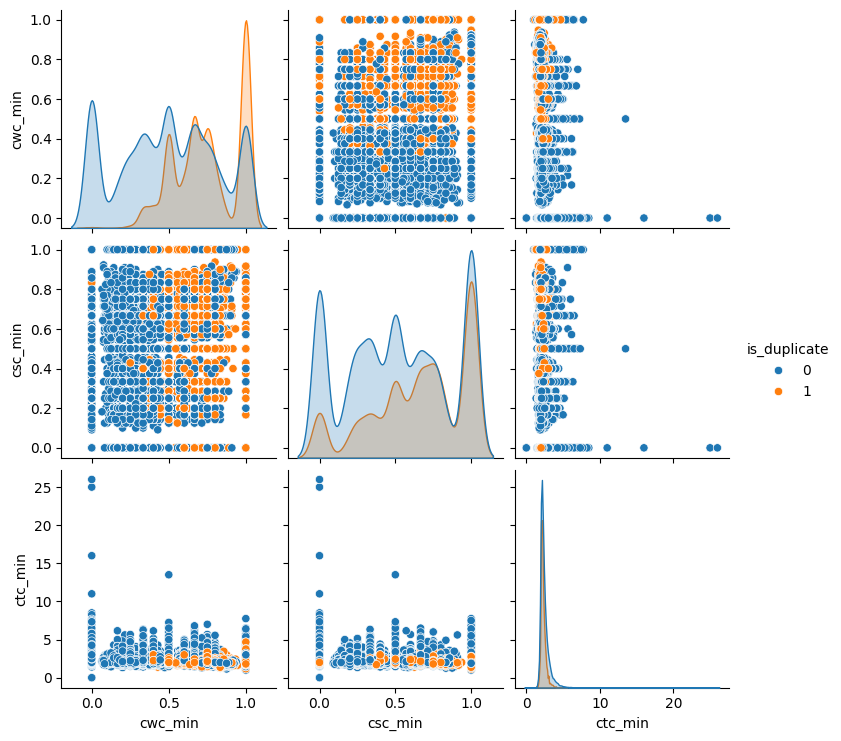

In [169]:
sns.pairplot(sample[['cwc_min','csc_min','ctc_min','is_duplicate']],hue='is_duplicate')

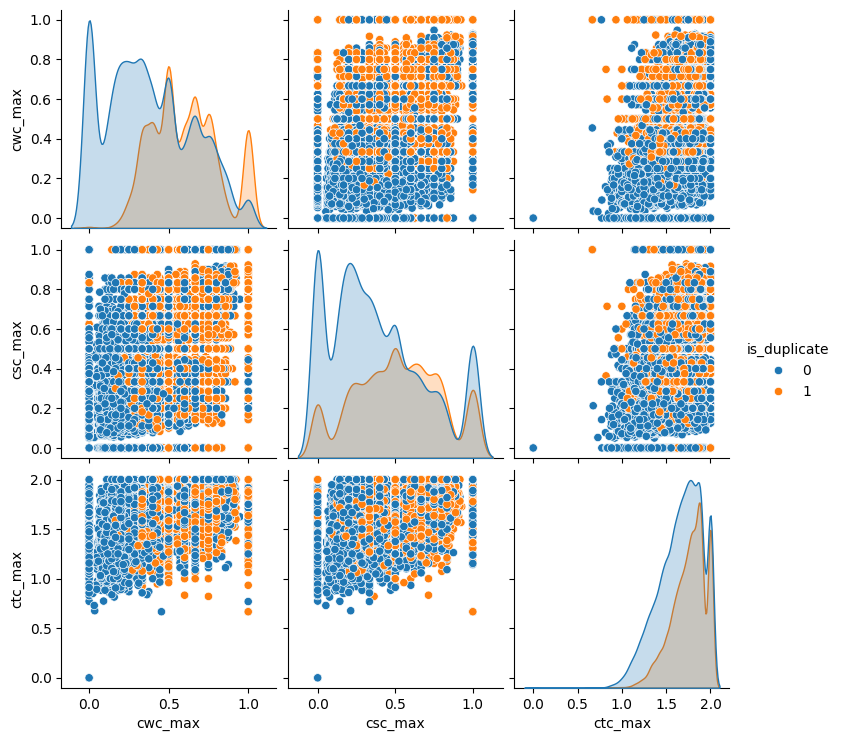

In [170]:
sns.pairplot(sample[['cwc_max','csc_max','ctc_max','is_duplicate']],hue='is_duplicate')

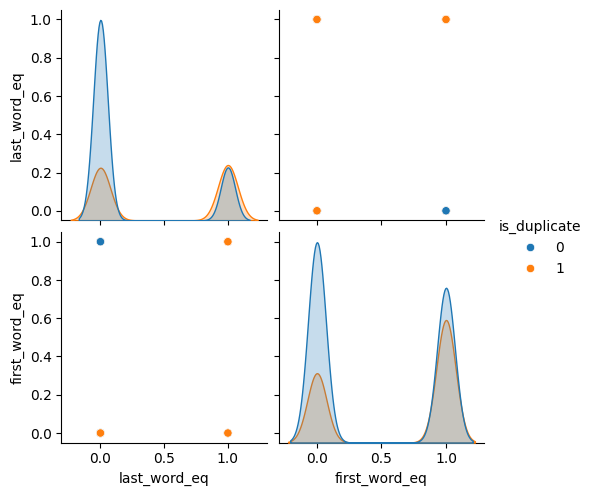

In [171]:
sns.pairplot(sample[['last_word_eq','first_word_eq','is_duplicate']],hue='is_duplicate')

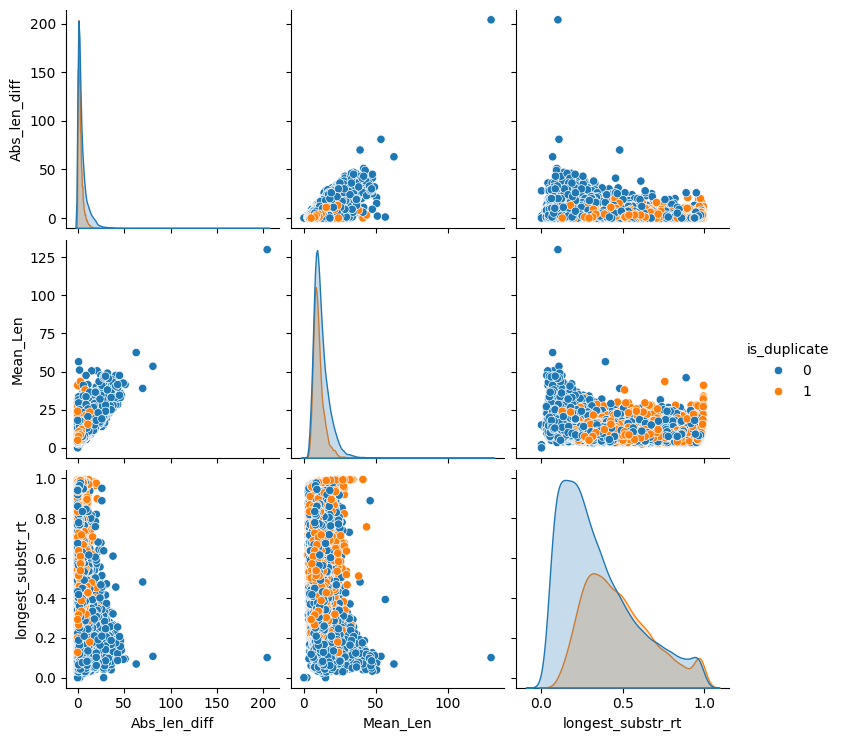

In [172]:
sns.pairplot(sample[['Abs_len_diff','Mean_Len','longest_substr_rt','is_duplicate']],hue='is_duplicate')

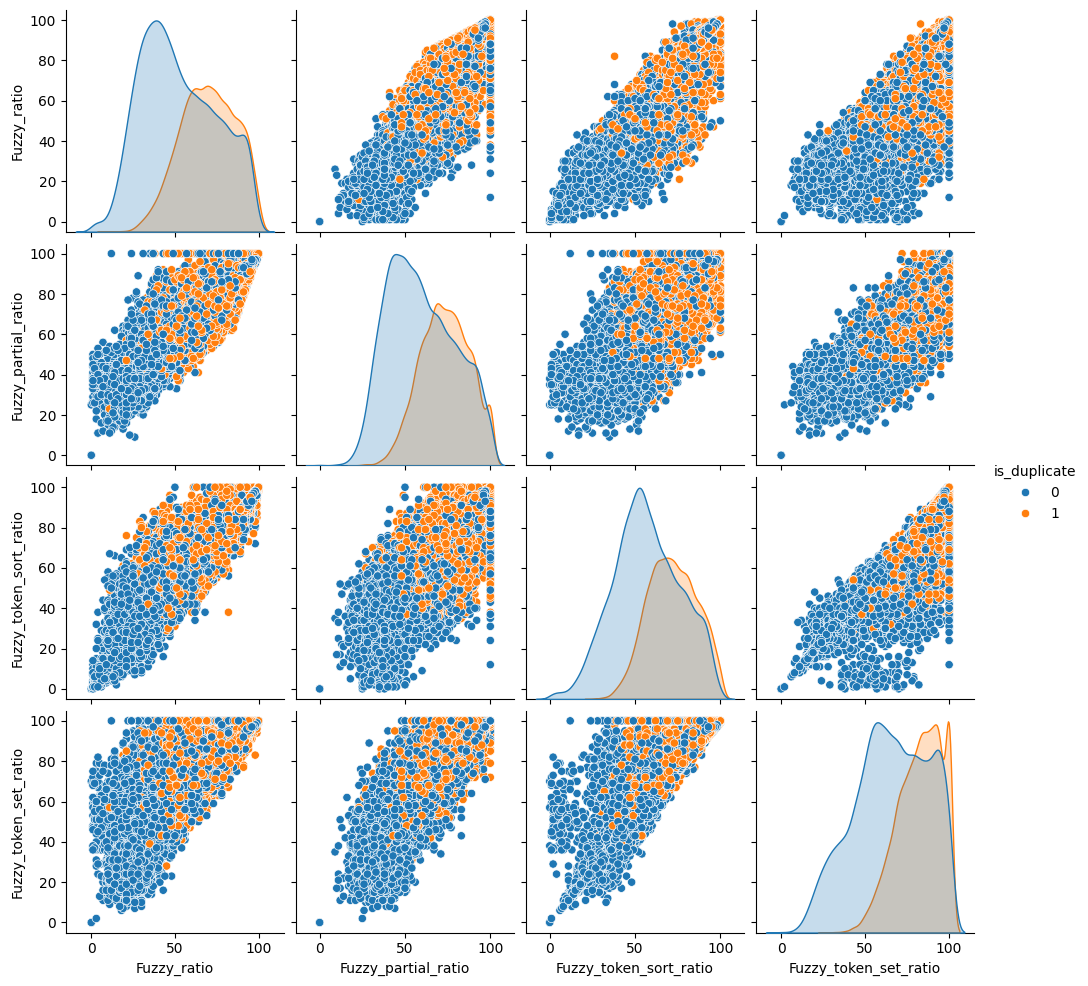

In [173]:
sns.pairplot(sample[['Fuzzy_ratio','Fuzzy_partial_ratio','Fuzzy_token_sort_ratio','Fuzzy_token_set_ratio','is_duplicate']],hue='is_duplicate')

In [174]:
ques_df = sample[['question1','question2']]


In [175]:
final_df = sample.drop(['id','qid1','qid2','question1','question2'],axis=1)
final_df.head()
final_df.shape

(30000, 23)

In [176]:
from sklearn.feature_extraction.text import CountVectorizer
# merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [177]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(30000, 6000)

In [178]:
final_df = pd.concat([final_df,temp_df],axis=1)
print(final_df.shape)
final_df.head()

(30000, 6023)


,is_duplicate,q1_len,q2_len,word_count1,word_count2,common_word_count,total_word_count,common_share,cwc_min,cwc_max,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
8067,0,33,33,8,8,7,16,0.437500,0.749981,0.749981,...,0,0,0,0,0,0,0,0,0,0
368101,0,52,50,11,9,6,20,0.300000,0.399992,0.399992,...,0,0,0,0,0,0,0,0,0,0
70497,0,94,44,16,8,2,24,0.083333,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
226567,1,43,51,7,9,6,16,0.375000,0.999975,0.999975,...,0,0,0,0,0,0,0,0,0,0
73186,1,37,28,9,7,4,16,0.250000,0.749981,0.599988,...,0,0,0,0,0,0,0,0,0,0


In [179]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.3,random_state=42)

In [180]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf =RandomForestClassifier()
rf.fit(X_train,y_train)
model = rf.predict(X_test)

print(accuracy_score(y_test,model))

0.7886666666666666


In [181]:
from xgboost import XGBClassifier

xgb =XGBClassifier()
xgb.fit(X_train,y_train)
model1 = xgb.predict(X_test)

print(accuracy_score(y_test,model1))

0.788


In [182]:
from sklearn.metrics import classification_report,confusion_matrix

print(confusion_matrix(y_test,model))
print(classification_report(y_test,model))

[[4926  781]
 [1121 2172]]
              precision    recall  f1-score   support

           0       0.81      0.86      0.84      5707
           1       0.74      0.66      0.70      3293

    accuracy                           0.79      9000
   macro avg       0.78      0.76      0.77      9000
weighted avg       0.79      0.79      0.79      9000



In [183]:
import pickle

pickle.dump(rf,open('model.pkl','wb'))
pickle.dump(cv,open('cv.pkl','wb'))

In [128]:
pickle.dump(stopwords,open('stopwords.pkl','wb'))

In [187]:
def test_common_words(q1,q2):
    w1 = set(map(lambda word: word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), q2.split(" ")))
    return len(w1 & w2)

def test_total_words(q1,q2):
    w1 = set(map(lambda word: word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), q2.split(" ")))
    return (len(w1) + len(w2))


def test_fetch_token_features(q1, q2):
    SAFE_DIV = 0.0001

    STOP_WORDS = stopwords.words('english')

    token_features = [0.0] * 8

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    # Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))

    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))

    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)

    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features


def test_fetch_length_features(q1, q2):
    length_features = [0.0] * 3

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features

    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))

    # Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens)) / 2

    strr = list(distance.lcsubstrings(q1, q2))
    if len(strr)==0:
        length_features[2]=0
    else:
        length_features[2] = len(strr[0]) / (min(len(q1), len(q2)) + 1)

    return length_features


def test_fetch_fuzzy_features(q1, q2):
    fuzzy_features = [0.0] * 4

    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features


def preprocess(q):
    q = str(q).lower().strip()

    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')

    # The pattern '[math]' appears around 900 times in the whole dataset.
    q = q.replace('[math]', '')

    # Replacing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)

    # Decontracting words
    contractions = {
        "ain't": "am not",
        "aren't": "are not",
        "can't": "can not",
        "can't've": "can not have",
        "'cause": "because",
        "could've": "could have",
        "couldn't": "could not",
        "couldn't've": "could not have",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hadn't've": "had not have",
        "hasn't": "has not",
        "haven't": "have not",
        "he'd": "he would",
        "he'd've": "he would have",
        "he'll": "he will",
        "he'll've": "he will have",
        "he's": "he is",
        "how'd": "how did",
        "how'd'y": "how do you",
        "how'll": "how will",
        "how's": "how is",
        "i'd": "i would",
        "i'd've": "i would have",
        "i'll": "i will",
        "i'll've": "i will have",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it'd": "it would",
        "it'd've": "it would have",
        "it'll": "it will",
        "it'll've": "it will have",
        "it's": "it is",
        "let's": "let us",
        "ma'am": "madam",
        "mayn't": "may not",
        "might've": "might have",
        "mightn't": "might not",
        "mightn't've": "might not have",
        "must've": "must have",
        "mustn't": "must not",
        "mustn't've": "must not have",
        "needn't": "need not",
        "needn't've": "need not have",
        "o'clock": "of the clock",
        "oughtn't": "ought not",
        "oughtn't've": "ought not have",
        "shan't": "shall not",
        "sha'n't": "shall not",
        "shan't've": "shall not have",
        "she'd": "she would",
        "she'd've": "she would have",
        "she'll": "she will",
        "she'll've": "she will have",
        "she's": "she is",
        "should've": "should have",
        "shouldn't": "should not",
        "shouldn't've": "should not have",
        "so've": "so have",
        "so's": "so as",
        "that'd": "that would",
        "that'd've": "that would have",
        "that's": "that is",
        "there'd": "there would",
        "there'd've": "there would have",
        "there's": "there is",
        "they'd": "they would",
        "they'd've": "they would have",
        "they'll": "they will",
        "they'll've": "they will have",
        "they're": "they are",
        "they've": "they have",
        "to've": "to have",
        "wasn't": "was not",
        "we'd": "we would",
        "we'd've": "we would have",
        "we'll": "we will",
        "we'll've": "we will have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what'll": "what will",
        "what'll've": "what will have",
        "what're": "what are",
        "what's": "what is",
        "what've": "what have",
        "when's": "when is",
        "when've": "when have",
        "where'd": "where did",
        "where's": "where is",
        "where've": "where have",
        "who'll": "who will",
        "who'll've": "who will have",
        "who's": "who is",
        "who've": "who have",
        "why's": "why is",
        "why've": "why have",
        "will've": "will have",
        "won't": "will not",
        "won't've": "will not have",
        "would've": "would have",
        "wouldn't": "would not",
        "wouldn't've": "would not have",
        "y'all": "you all",
        "y'all'd": "you all would",
        "y'all'd've": "you all would have",
        "y'all're": "you all are",
        "y'all've": "you all have",
        "you'd": "you would",
        "you'd've": "you would have",
        "you'll": "you will",
        "you'll've": "you will have",
        "you're": "you are",
        "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")

    # Removing HTML tags
    q = BeautifulSoup(q,'html.parser')
    q = q.get_text()

    # Remove punctuations
    pattern = re.compile(r'[^\w\s]')
    q = re.sub(pattern, ' ', q).strip()

    return q


def query_point_creator(q1, q2):
    input_query = []

    # preprocess
    q1 = preprocess(q1)
    q2 = preprocess(q2)

    # fetch basic features
    input_query.append(len(q1))
    input_query.append(len(q2))

    input_query.append(len(q1.split(" ")))
    input_query.append(len(q2.split(" ")))

    input_query.append(test_common_words(q1, q2))
    input_query.append(test_total_words(q1, q2))
    input_query.append(round(test_common_words(q1, q2) / test_total_words(q1, q2), 2))

    # fetch token features
    token_features = test_fetch_token_features(q1, q2)
    input_query.extend(token_features)

    # fetch length based features
    length_features = test_fetch_length_features(q1, q2)
    input_query.extend(length_features)

    # fetch fuzzy features
    fuzzy_features = test_fetch_fuzzy_features(q1, q2)
    input_query.extend(fuzzy_features)

    # bow feature for q1
    q1_bow = cv.transform([q1]).toarray()

    # bow feature for q2
    q2_bow = cv.transform([q2]).toarray()

    return np.hstack((np.array(input_query).reshape(1, 22), q1_bow, q2_bow))

In [192]:
q1 = 'Where is the capital of India?'
q2 = 'What is the current capital of Pakistan?'
q3 = 'Where is the capital of India?'
q4 = 'What is the business capital of India?'

In [193]:
rf.predict(query_point_creator(q1,q3))

array([1])